In [1]:
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124 -q

In [2]:
!pip uninstall torch torchvision torchaudio -y

In [3]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124 -q

In [4]:
import os
import pandas as pd 
import os
# os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

BASE = '/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset'
FRAME_DIR = f"{BASE}/embryo_dataset/embryo_dataset"
ANNOT_DIR  = f"{BASE}/embryo_dataset_annotations/embryo_dataset_annotations"
video_folders = sorted(os.listdir(FRAME_DIR))
csv_files     = sorted(os.listdir(ANNOT_DIR))

print(f"Video folders: {len(video_folders)}")
print(f"CSV files:     {len(csv_files)}")

Video folders: 704
CSV files:     704


In [5]:
import pandas as pd
import os

PREFIX_MAP_CSV = '/kaggle/working/prefix_map.csv'

if os.path.exists(PREFIX_MAP_CSV):
    # load from saved csv
    prefix_map = pd.read_csv(PREFIX_MAP_CSV).set_index('video')['prefix'].to_dict()
    print(f"Loaded prefix map for {len(prefix_map)} videos from cache")

else:
    # build and save
    prefix_map = {}
    for video in video_folders:
        frames = os.listdir(os.path.join(FRAME_DIR, video))
        if frames:
            prefix_map[video] = frames[0].rsplit("_RUN", 1)[0]

    pd.DataFrame(list(prefix_map.items()),
                 columns=['video', 'prefix']).to_csv(PREFIX_MAP_CSV, index=False)
    print(f"Built and saved prefix map for {len(prefix_map)} videos → {PREFIX_MAP_CSV}")

Loaded prefix map for 704 videos from cache


In [6]:
from tqdm import tqdm

all_records = []
missing_frames = 0
for csv_file in tqdm(csv_files, desc = "Processing CSVs"):
    video_name = csv_file.replace("_phases.csv", "")
    video_frame_dir = os.path.join(FRAME_DIR, video_name)
    if not os.path.exists(video_frame_dir):
        continue
    if video_name not in prefix_map:
        continue
    prefix = prefix_map[video_name]
    frame_files = set(os.listdir(video_frame_dir))
    df = pd.read_csv(os.path.join(ANNOT_DIR, csv_file),
                     header=None,
                     names=["phase", "start_frame", "end_frame"])
    
    for row in df.itertuples(index=False):  # faster than iterrows
        phase = str(row.phase).strip()
        start_frame = int(row.start_frame)
        end_frame = int(row.end_frame)

        for frame_idx in range(start_frame, end_frame + 1):
            filename = f"{prefix}_RUN{frame_idx}.jpeg"

            if filename not in frame_files:
                missing_frames += 1
                continue

            all_records.append({
                "video": video_name,
                "frame_path": os.path.join(video_frame_dir, filename),
                "frame_idx": frame_idx,
                "label": phase
            })
            
master_df = pd.DataFrame(all_records)
print(f"\nTotal frames indexed: {len(master_df)}")
print(f"Missing frames skipped: {missing_frames}")
print(f"\nClass distribution:\n{master_df['label'].value_counts()}")
print(f"\nUnique classes: {sorted(master_df['label'].unique())}")

Processing CSVs: 100%|██████████| 704/704 [01:02<00:00, 11.24it/s]



Total frames indexed: 297428
Missing frames skipped: 4706

Class distribution:
label
t9+     51112
tPNa    43244
t8      32602
t2      29189
t4      29177
tEB     19535
tSB     17244
tM      17084
t7      10531
tB      10387
tPB2     8895
t6       8366
t5       8045
tPNf     6793
t3       5127
tHB        97
Name: count, dtype: int64

Unique classes: ['t2', 't3', 't4', 't5', 't6', 't7', 't8', 't9+', 'tB', 'tEB', 'tHB', 'tM', 'tPB2', 'tPNa', 'tPNf', 'tSB']


In [7]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image , ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

CLASSES = ['tPB2', 'tPNa', 'tPNf', 't2', 't3', 't4', 't5',
           't6', 't7', 't8', 't9+', 'tM', 'tSB', 'tB', 'tEB', 'tHB']

CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}
NUM_CLASSES  = len(CLASSES)

# ─────────────────────────────────────────────
# DATASET
# ─────────────────────────────────────────────
class EmbryoDataset(Dataset):
    """Args:
        df : master_df with columns ['video','frame_path', 'frame_idx','label']
        transform : torchvision transform pipeline
        class_to_idx : optional 
    """
    def __init__(self,df,transform = None , class_to_idx = CLASS_TO_IDX):
        self.df = df.reset_index(drop = True)
        self.transform = transform 
        self.class_to_idx = class_to_idx
    def __len__(self):
        return len(self.df)
    def __getitem__(self,idx):
        row       = self.df.iloc[idx]
        label_idx = self.class_to_idx[row['label']]
        try:
            image = Image.open(row['frame_path']).convert('RGB')
        except (OSError, Exception):
            image = Image.new('RGB', (224, 224), 0)
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label_idx, dtype=torch.long)
        




In [8]:

# ─────────────────────────────────────────────
# TRANSFORMS
# ─────────────────────────────────────────────
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
# MobileNet, VGG16, VGG19  —  224 x 224
standard_train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

standard_val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])


# InceptionV3  —  299 x 299
inception_train_transforms = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

inception_val_transforms = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])






In [9]:
# ─────────────────────────────────────────────
# TRAIN / VAL SPLIT  (group-safe: split by video, not frame)
# ─────────────────────────────────────────────
from sklearn.model_selection import GroupShuffleSplit

groups = master_df['video'].values          # one group = one embryo video

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(master_df, groups=groups))

train_df = master_df.iloc[train_idx].reset_index(drop=True)
val_df   = master_df.iloc[val_idx].reset_index(drop=True)



print(f"Train frames : {len(train_df)}")
print(f"Val frames   : {len(val_df)}")
print(f"Train videos : {train_df['video'].nunique()}")
print(f"Val videos   : {val_df['video'].nunique()}")


Train frames : 236123
Val frames   : 61305
Train videos : 563
Val videos   : 141


In [10]:
train_ds_standard  = EmbryoDataset(train_df, transform=standard_train_transforms)
val_ds_standard    = EmbryoDataset(val_df,   transform=standard_val_transforms)

train_ds_inception = EmbryoDataset(train_df, transform=inception_train_transforms)
val_ds_inception   = EmbryoDataset(val_df,   transform=inception_val_transforms)

print(f"Train size: {len(train_ds_standard)} | Val size: {len(val_ds_standard)}")

Train size: 236123 | Val size: 61305


In [11]:
import torch
import torch.nn as nn
from torchvision import models


# ─────────────────────────────────────────────
# UNIFIED MODEL FACTORY
# ─────────────────────────────────────────────
def build_model(model_name: str, num_classes: int = NUM_CLASSES, freeze: bool = True) -> nn.Module:
    """
    Build a pretrained feature extractor + single linear output head.

    Supported model_name values:
        'mobilenet'  → MobileNetV2
        'inception'  → InceptionV3  (input size 299×299)
        'vgg16'      → VGG-16
        'vgg19'      → VGG-19
        'resnet50'   → ResNet-50

    Args:
        model_name : architecture string (case-insensitive)
        num_classes: number of output classes
        freeze     : if True, freeze backbone; only the final linear head is trained

    Returns:
        nn.Module with .trainable_params() and .total_params() helpers attached
    """
    model_name = model_name.lower().strip()

    # ── MobileNetV2 ─────────────────────────────────────────────────
    if model_name == 'mobilenet':
        net = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        if freeze:
            for p in net.features.parameters():
                p.requires_grad = False
        in_features = net.classifier[1].in_features
        net.classifier = nn.Linear(in_features, num_classes)

    # ── InceptionV3 ─────────────────────────────────────────────────
    elif model_name == 'inception':
        net = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT)
        net.aux_logits = False          # disable auxiliary classifier
        if freeze:
            for name, p in net.named_parameters():
                if 'fc' not in name:
                    p.requires_grad = False
        in_features = net.fc.in_features
        net.fc = nn.Linear(in_features, num_classes)

    # ── VGG-16 ──────────────────────────────────────────────────────
    elif model_name == 'vgg16':
        net = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        if freeze:
            for p in net.features.parameters():
                p.requires_grad = False
        in_features = net.classifier[0].in_features
        net.classifier = nn.Linear(in_features, num_classes)

    # ── VGG-19 ──────────────────────────────────────────────────────
    elif model_name == 'vgg19':
        net = models.vgg19(weights=models.VGG19_Weights.DEFAULT)
        if freeze:
            for p in net.features.parameters():
                p.requires_grad = False
        in_features = net.classifier[0].in_features
        net.classifier = nn.Linear(in_features, num_classes)

    # ── ResNet-50 ───────────────────────────────────────────────────
    elif model_name == 'resnet50':
        net = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        if freeze:
            for name, p in net.named_parameters():
                if 'fc' not in name:
                    p.requires_grad = False
        in_features = net.fc.in_features
        net.fc = nn.Linear(in_features, num_classes)

    else:
        raise ValueError(
            f"Unknown model_name='{model_name}'. "
            f"Choose from: mobilenet, inception, vgg16, vgg19, resnet50"
        )

    # Attach lightweight helpers so the rest of the notebook can call
    # model.trainable_params() / model.total_params() as before.
    net.trainable_params = lambda: sum(p.numel() for p in net.parameters() if p.requires_grad)
    net.total_params     = lambda: sum(p.numel() for p in net.parameters())

    return net


In [12]:
import torch.nn as nn
import torch.nn.functional as F


# ─────────────────────────────────────────────
# LOSS:  Cross-Entropy  +  Expected Rank Distance (ERD)
# ─────────────────────────────────────────────
class OrdinalCEERDLoss(nn.Module):
    """
    Combines two terms:

    1. Cross-Entropy (CE) — standard multi-class classification loss.

    2. Expected Rank Distance (ERD) — ordinal-aware regulariser.
       For each sample the model produces a softmax distribution over
       class indices {0, 1, ..., C-1}.  The *expected* (mean) predicted
       rank is:
           E[rank] = Σ_i  i · softmax_i
       ERD is the mean absolute error between E[rank] and the true
       integer rank, normalised to [0, 1] by dividing by (C − 1).

    Why ERD instead of the CDF-L2 EMD from before?
    • EMD penalises the *integral* of the squared CDF gap (global shape).
    • ERD penalises the *first-moment* error (ordinal position of the
      predicted centre-of-mass) — complementary, lighter to compute,
      and interpretable as normalised mean absolute rank error.

    total_loss = CE  +  lambda_dist · ERD
    """

    def __init__(self, num_classes: int, lambda_dist: float = 0.5):
        super().__init__()
        self.num_classes = num_classes
        self.lambda_dist = lambda_dist
        self.CE          = nn.CrossEntropyLoss()
        # rank indices {0, …, C-1} — registered as a buffer so they
        # automatically move to the correct device with .to(device)
        self.register_buffer(
            'rank_weights',
            torch.arange(num_classes, dtype=torch.float32)
        )

    def erd_loss(self, logits: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        probs         = F.softmax(logits, dim=1)                   # (B, C)
        expected_rank = (probs * self.rank_weights).sum(dim=1)     # (B,)
        true_rank     = labels.float()                             # (B,)
        abs_err       = torch.abs(expected_rank - true_rank)       # (B,)
        return abs_err.mean() / (self.num_classes - 1)             # ∈ [0, 1]

    def forward(self, logits: torch.Tensor, labels: torch.Tensor):
        ce_loss   = self.CE(logits, labels)
        dist_loss = self.erd_loss(logits, labels)
        total     = ce_loss + self.lambda_dist * dist_loss
        return total, ce_loss, dist_loss


In [13]:
# ─────────────────────────────────────────────
# INSTANTIATE ALL 5 MODELS
# ─────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

_model_names = ['mobilenet', 'vgg16', 'vgg19', 'inception', 'resnet50']
models_dict  = {name: build_model(name).to(DEVICE) for name in _model_names}

# convenient short-hand variables kept for backward compat with the loaders below
mobilenet = models_dict['mobilenet']
vgg16     = models_dict['vgg16']
vgg19     = models_dict['vgg19']
inception = models_dict['inception']
resnet50  = models_dict['resnet50']

print(f"{'Model':<12} {'Total Params':>15} {'Trainable':>12} {'Frozen':>12}")
print("-" * 55)
for name, m in models_dict.items():
    total     = m.total_params()
    trainable = m.trainable_params()
    print(f"{name:<12} {total:>15,} {trainable:>12,} {total-trainable:>12,}")


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 181MB/s]
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:02<00:00, 214MB/s] 
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:02<00:00, 208MB/s] 
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 197MB/s] 
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 231MB/s]


Model           Total Params    Trainable       Frozen
-------------------------------------------------------
mobilenet          2,244,368       20,496    2,223,872
vgg16             15,116,112      401,424   14,714,688
vgg19             20,425,808      401,424   20,024,384
inception         25,145,048      801,784   24,343,264
resnet50          23,540,816       32,784   23,508,032


In [14]:
# ─────────────────────────────────────────────
# TRAINING FUNCTION
# ─────────────────────────────────────────────
import os
import time
from tqdm import tqdm


def train_model(
    model,
    model_name,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs,
    checkpoint_dir,
    device=DEVICE,
    scheduler=None,
):
    os.makedirs(checkpoint_dir, exist_ok=True)

    history = {
        'train_loss': [], 'train_ce': [], 'train_dist': [], 'train_acc': [],
        'val_loss':   [], 'val_ce':   [], 'val_dist':   [], 'val_acc':   [],
    }
    best_val_acc = 0.0

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        # ── TRAIN ─────────────────────────────────────────────────────
        model.train()
        train_loss = train_ce = train_dist = correct = total = 0

        pbar = tqdm(train_loader,
                    desc=f"[{model_name}] Ep {epoch:02d}/{epochs} TRAIN",
                    leave=False)

        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            logits = model(imgs)
            loss, ce, dist = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            bs          = labels.size(0)
            train_loss += loss.item() * bs
            train_ce   += ce.item()   * bs
            train_dist += dist.item() * bs
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += bs

            pbar.set_postfix(loss=f"{loss.item():.4f}",
                             acc=f"{correct/total:.3f}")

        train_loss /= total
        train_ce   /= total
        train_dist /= total
        train_acc   = correct / total

        # ── VAL ───────────────────────────────────────────────────────
        model.eval()
        val_loss = val_ce = val_dist = v_correct = v_total = 0

        with torch.no_grad():
            for imgs, labels in tqdm(val_loader,
                                     desc=f"[{model_name}] Ep {epoch:02d}/{epochs} VAL  ",
                                     leave=False):
                imgs, labels   = imgs.to(device), labels.to(device)
                logits          = model(imgs)
                loss, ce, dist  = criterion(logits, labels)

                bs         = labels.size(0)
                val_loss  += loss.item() * bs
                val_ce    += ce.item()   * bs
                val_dist  += dist.item() * bs
                v_correct += (logits.argmax(1) == labels).sum().item()
                v_total   += bs

        val_loss /= v_total
        val_ce   /= v_total
        val_dist /= v_total
        val_acc   = v_correct / v_total

        if scheduler:
            scheduler.step()

        # ── LOG ───────────────────────────────────────────────────────
        elapsed = time.time() - t0
        print(
            f"[{model_name}] Ep {epoch:02d}/{epochs} | "
            f"Train  loss={train_loss:.4f} ce={train_ce:.4f} dist={train_dist:.4f} acc={train_acc:.3f} | "
            f"Val    loss={val_loss:.4f}  ce={val_ce:.4f}  dist={val_dist:.4f}  acc={val_acc:.3f} | "
            f"{elapsed:.1f}s"
        )

        history['train_loss'].append(train_loss)
        history['train_ce'].append(train_ce)
        history['train_dist'].append(train_dist)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_ce'].append(val_ce)
        history['val_dist'].append(val_dist)
        history['val_acc'].append(val_acc)

        # ── CHECKPOINT ────────────────────────────────────────────────
        ckpt = {
            'epoch':       epoch,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'val_acc':     val_acc,
            'history':     history,
        }
        torch.save(ckpt, os.path.join(checkpoint_dir, f"{model_name}_last.pth"))

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(ckpt, os.path.join(checkpoint_dir, f"{model_name}_best.pth"))
            print(f"  ✓ Best model saved (val_acc={best_val_acc:.3f})")

    return history


In [15]:
BATCH_SIZE = 256
EPOCHES = 5
LR = 1e-3
standard_train_loader = DataLoader(train_ds_standard, batch_size=BATCH_SIZE,
                                   shuffle=True,  num_workers=4, pin_memory=True)
standard_val_loader   = DataLoader(val_ds_standard,   batch_size=BATCH_SIZE,
                                   shuffle=False, num_workers=4, pin_memory=True)

inception_train_loader = DataLoader(train_ds_inception, batch_size=BATCH_SIZE,
                                    shuffle=True,  num_workers=4, pin_memory=True)
inception_val_loader   = DataLoader(val_ds_inception,   batch_size=BATCH_SIZE,
                                    shuffle=False, num_workers=4, pin_memory=True)

# sanity check
imgs, labels = next(iter(standard_train_loader))
print(f"Standard  → {imgs.shape}")   # (32, 3, 224, 224)

# imgs, labels = next(iter(inception_train_loader))
# print(f"Inception → {imgs.shape}")   # (32, 3, 299, 299)

Standard  → torch.Size([256, 3, 224, 224])


In [16]:
DEVICE

device(type='cuda')

In [17]:
# ── Train all 5 models ────────────────────────────────────────────
all_histories = {}

model_configs = [
    # ('mobilenet', mobilenet, standard_train_loader,   standard_val_loader),
    ('vgg16',     vgg16,     standard_train_loader,   standard_val_loader),
    ('vgg19',     vgg19,     standard_train_loader,   standard_val_loader),
    ('resnet50',  resnet50,  standard_train_loader,   standard_val_loader),
    ('inception', inception, inception_train_loader,  inception_val_loader),
]

for model_name, model, train_loader, val_loader in model_configs:
    print(f"\n{'='*60}")
    print(f"  Training {model_name.upper()}")
    print(f"{'='*60}")

    # criterion = OrdinalCEERDLoss(num_classes=NUM_CLASSES, lambda_dist=0.5)
    criterion = OrdinalCEERDLoss(num_classes=NUM_CLASSES, lambda_dist=0.5).to(DEVICE)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR
    )

    history = train_model(
        model          = model,
        model_name     = model_name,
        train_loader   = train_loader,
        val_loader     = val_loader,
        criterion      = criterion,
        optimizer      = optimizer,
        epochs         = EPOCHES,
        checkpoint_dir = './checkpoints',
        device         = DEVICE,
    )
    all_histories[model_name] = history
    break



  Training VGG16


[vgg16] Ep 01/5 | Train  loss=1.2456 ce=1.2145 dist=0.0621 acc=0.600 | Val    loss=1.9863  ce=1.9489  dist=0.0749  acc=0.474 | 1099.4s
  ✓ Best model saved (val_acc=0.474)


[vgg16] Ep 02/5 | Train  loss=1.0061 ce=0.9826 dist=0.0469 acc=0.675 | Val    loss=2.2192  ce=2.1807  dist=0.0771  acc=0.452 | 928.7s


[vgg16] Ep 03/5 | Train  loss=0.9360 ce=0.9147 dist=0.0426 acc=0.700 | Val    loss=2.2709  ce=2.2321  dist=0.0777  acc=0.457 | 913.3s


[vgg16] Ep 04/5 | Train  loss=0.9086 ce=0.8884 dist=0.0404 acc=0.710 | Val    loss=2.5491  ce=2.5082  dist=0.0818  acc=0.454 | 921.4s


[vgg16] Ep 05/5 | Train  loss=0.8822 ce=0.8629 dist=0.0386 acc=0.721 | Val    loss=2.6238  ce=2.5850  dist=0.0777  acc=0.472 | 908.8s


In [18]:
# ── Train all 5 models ────────────────────────────────────────────
all_histories = {}

model_configs = [
    # ('mobilenet', mobilenet, standard_train_loader,   standard_val_loader),
    # ('vgg16',     vgg16,     standard_train_loader,   standard_val_loader),
    # ('vgg19',     vgg19,     standard_train_loader,   standard_val_loader),
    ('resnet50',  resnet50,  standard_train_loader,   standard_val_loader),
    ('inception', inception, inception_train_loader,  inception_val_loader),
]

for model_name, model, train_loader, val_loader in model_configs:
    print(f"\n{'='*60}")
    print(f"  Training {model_name.upper()}")
    print(f"{'='*60}")

    # criterion = OrdinalCEERDLoss(num_classes=NUM_CLASSES, lambda_dist=0.5)
    criterion = OrdinalCEERDLoss(num_classes=NUM_CLASSES, lambda_dist=0.5).to(DEVICE)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR
    )

    history = train_model(
        model          = model,
        model_name     = model_name,
        train_loader   = train_loader,
        val_loader     = val_loader,
        criterion      = criterion,
        optimizer      = optimizer,
        epochs         = EPOCHES,
        checkpoint_dir = './checkpoints',
        device         = DEVICE,
    )
    all_histories[model_name] = history
    break



  Training VGG19


[vgg19] Ep 01/5 | Train  loss=1.2927 ce=1.2588 dist=0.0679 acc=0.581 | Val    loss=1.9842  ce=1.9439  dist=0.0806  acc=0.454 | 923.6s
  ✓ Best model saved (val_acc=0.454)


[vgg19] Ep 02/5 | Train  loss=1.0607 ce=1.0348 dist=0.0519 acc=0.654 | Val    loss=2.1292  ce=2.0889  dist=0.0805  acc=0.448 | 928.3s


[vgg19] Ep 03/5 | Train  loss=0.9811 ce=0.9574 dist=0.0474 acc=0.681 | Val    loss=2.2606  ce=2.2214  dist=0.0783  acc=0.459 | 918.4s
  ✓ Best model saved (val_acc=0.459)


[vgg19] Ep 04/5 | Train  loss=0.9508 ce=0.9283 dist=0.0449 acc=0.692 | Val    loss=2.5832  ce=2.5417  dist=0.0830  acc=0.438 | 923.1s


[vgg19] Ep 05/5 | Train  loss=0.9196 ce=0.8982 dist=0.0429 acc=0.702 | Val    loss=2.6682  ce=2.6274  dist=0.0815  acc=0.446 | 911.7s


In [19]:
# ── Train all 5 models ────────────────────────────────────────────
all_histories = {}

model_configs = [
    # ('mobilenet', mobilenet, standard_train_loader,   standard_val_loader),
    # ('vgg16',     vgg16,     standard_train_loader,   standard_val_loader),
    # ('vgg19',     vgg19,     standard_train_loader,   standard_val_loader),
    # ('resnet50',  resnet50,  standard_train_loader,   standard_val_loader),
    ('inception', inception, inception_train_loader,  inception_val_loader),
]

for model_name, model, train_loader, val_loader in model_configs:
    print(f"\n{'='*60}")
    print(f"  Training {model_name.upper()}")
    print(f"{'='*60}")

    # criterion = OrdinalCEERDLoss(num_classes=NUM_CLASSES, lambda_dist=0.5)
    criterion = OrdinalCEERDLoss(num_classes=NUM_CLASSES, lambda_dist=0.5).to(DEVICE)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR
    )

    history = train_model(
        model          = model,
        model_name     = model_name,
        train_loader   = train_loader,
        val_loader     = val_loader,
        criterion      = criterion,
        optimizer      = optimizer,
        epochs         = EPOCHES,
        checkpoint_dir = './checkpoints',
        device         = DEVICE,
    )
    all_histories[model_name] = history
    break



  Training INCEPTION


[inception] Ep 01/5 | Train  loss=1.7710 ce=1.7108 dist=0.1204 acc=0.436 | Val    loss=1.6910  ce=1.6410  dist=0.0999  acc=0.455 | 1158.3s
  ✓ Best model saved (val_acc=0.455)


[inception] Ep 02/5 | Train  loss=1.6486 ce=1.5974 dist=0.1024 acc=0.459 | Val    loss=1.6865  ce=1.6375  dist=0.0980  acc=0.447 | 1125.5s


[inception] Ep 03/5 | Train  loss=1.6390 ce=1.5888 dist=0.1005 acc=0.461 | Val    loss=1.6464  ce=1.5991  dist=0.0945  acc=0.475 | 1124.8s
  ✓ Best model saved (val_acc=0.475)


[inception] Ep 04/5 | Train  loss=1.6379 ce=1.5880 dist=0.0999 acc=0.461 | Val    loss=1.6526  ce=1.6058  dist=0.0936  acc=0.463 | 1124.1s


[inception] Ep 05/5 | Train  loss=1.6352 ce=1.5855 dist=0.0994 acc=0.462 | Val    loss=1.6447  ce=1.5975  dist=0.0943  acc=0.457 | 1122.1s


In [20]:
# ── Train all 5 models ────────────────────────────────────────────
all_histories = {}

model_configs = [
    ('mobilenet', mobilenet, standard_train_loader,   standard_val_loader),
    # ('vgg16',     vgg16,     standard_train_loader,   standard_val_loader),
    # ('vgg19',     vgg19,     standard_train_loader,   standard_val_loader),
    # ('resnet50',  resnet50,  standard_train_loader,   standard_val_loader),
    # ('inception', inception, inception_train_loader,  inception_val_loader),
]

for model_name, model, train_loader, val_loader in model_configs:
    print(f"\n{'='*60}")
    print(f"  Training {model_name.upper()}")
    print(f"{'='*60}")

    # criterion = OrdinalCEERDLoss(num_classes=NUM_CLASSES, lambda_dist=0.5)
    criterion = OrdinalCEERDLoss(num_classes=NUM_CLASSES, lambda_dist=0.5).to(DEVICE)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR
    )

    history = train_model(
        model          = model,
        model_name     = model_name,
        train_loader   = train_loader,
        val_loader     = val_loader,
        criterion      = criterion,
        optimizer      = optimizer,
        epochs         = EPOCHES,
        checkpoint_dir = './checkpoints',
        device         = DEVICE,
    )
    all_histories[model_name] = history
    break



  Training MOBILENET


[mobilenet] Ep 01/5 | Train  loss=1.7018 ce=1.6462 dist=0.1111 acc=0.459 | Val    loss=1.7606  ce=1.7081  dist=0.1050  acc=0.429 | 778.1s
  ✓ Best model saved (val_acc=0.429)


[mobilenet] Ep 02/5 | Train  loss=1.5064 ce=1.4618 dist=0.0892 acc=0.504 | Val    loss=1.7271  ce=1.6769  dist=0.1005  acc=0.436 | 791.2s
  ✓ Best model saved (val_acc=0.436)


[mobilenet] Ep 03/5 | Train  loss=1.4638 ce=1.4212 dist=0.0854 acc=0.514 | Val    loss=1.7028  ce=1.6543  dist=0.0969  acc=0.442 | 785.3s
  ✓ Best model saved (val_acc=0.442)


[mobilenet] Ep 04/5 | Train  loss=1.4413 ce=1.3995 dist=0.0835 acc=0.520 | Val    loss=1.7123  ce=1.6644  dist=0.0957  acc=0.442 | 829.4s


[mobilenet] Ep 05/5 | Train  loss=1.4273 ce=1.3862 dist=0.0822 acc=0.524 | Val    loss=1.6972  ce=1.6501  dist=0.0941  acc=0.446 | 812.3s
  ✓ Best model saved (val_acc=0.446)


In [22]:
from IPython.display import FileLink

# Replace with your file name
file_path = "/kaggle/working/checkpoints/mobilenet_best.pth"

FileLink(file_path)

/kaggle/working/checkpoints/mobilenet_best.pth

In [23]:
# ─────────────────────────────────────────────
# LOAD BEST CHECKPOINTS FOR ALL 4 TRAINED MODELS
# ─────────────────────────────────────────────
import torch
from collections import defaultdict

CHECKPOINT_DIR = './checkpoints'
TRAINED_MODELS = ['vgg16', 'vgg19', 'mobilenet', 'inception']

loaded_models   = {}   # name → model (eval mode, on DEVICE)
all_histories   = {}   # name → history dict from checkpoint

for name in TRAINED_MODELS:
    ckpt_path = f"{CHECKPOINT_DIR}/{name}_best.pth"
    ckpt      = torch.load(ckpt_path, map_location=DEVICE)

    model = build_model(name).to(DEVICE)
    model.load_state_dict(ckpt['model_state'])
    model.eval()

    loaded_models[name] = model
    all_histories[name] = ckpt['history']

    print(f"  ✓ {name:<10}  best val_acc = {ckpt['val_acc']:.4f}  "
          f"(epoch {ckpt['epoch']})")


  ✓ vgg16       best val_acc = 0.4736  (epoch 1)
  ✓ vgg19       best val_acc = 0.4589  (epoch 3)
  ✓ mobilenet   best val_acc = 0.4464  (epoch 5)
  ✓ inception   best val_acc = 0.4754  (epoch 3)



── VGG16 ──────────────────────────────────
              precision    recall  f1-score   support

        tPB2      0.591     0.080     0.141      1791
        tPNa      0.765     0.814     0.789      9079
        tPNf      0.219     0.603     0.322      1336
          t2      0.540     0.603     0.570      5803
          t3      0.028     0.007     0.011      1021
          t4      0.408     0.442     0.425      5616
          t5      0.127     0.040     0.061      1837
          t6      0.031     0.002     0.003      1758
          t7      0.163     0.095     0.120      2579
          t8      0.356     0.368     0.362      6567
         t9+      0.523     0.603     0.560     10645
          tM      0.262     0.298     0.279      3435
         tSB      0.391     0.455     0.421      3709
          tB      0.465     0.082     0.139      2281
         tEB      0.522     0.703     0.599      3758
         tHB      0.000     0.000     0.000        90

    accuracy                       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



── VGG19 ──────────────────────────────────
              precision    recall  f1-score   support

        tPB2      0.446     0.178     0.254      1791
        tPNa      0.722     0.870     0.789      9079
        tPNf      0.323     0.320     0.321      1336
          t2      0.506     0.643     0.566      5803
          t3      0.069     0.098     0.081      1021
          t4      0.381     0.175     0.240      5616
          t5      0.099     0.049     0.066      1837
          t6      0.029     0.003     0.005      1758
          t7      0.033     0.016     0.022      2579
          t8      0.340     0.410     0.372      6567
         t9+      0.495     0.621     0.551     10645
          tM      0.244     0.331     0.281      3435
         tSB      0.414     0.481     0.445      3709
          tB      0.405     0.156     0.225      2281
         tEB      0.563     0.523     0.542      3758
         tHB      0.000     0.000     0.000        90

    accuracy                       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



── MOBILENET ──────────────────────────────────
              precision    recall  f1-score   support

        tPB2      0.356     0.236     0.284      1791
        tPNa      0.704     0.847     0.769      9079
        tPNf      0.400     0.141     0.209      1336
          t2      0.446     0.554     0.494      5803
          t3      0.000     0.000     0.000      1021
          t4      0.333     0.327     0.330      5616
          t5      0.196     0.005     0.010      1837
          t6      0.089     0.002     0.004      1758
          t7      0.214     0.019     0.036      2579
          t8      0.296     0.231     0.259      6567
         t9+      0.408     0.740     0.526     10645
          tM      0.308     0.170     0.219      3435
         tSB      0.363     0.326     0.344      3709
          tB      0.322     0.207     0.252      2281
         tEB      0.508     0.614     0.556      3758
         tHB      0.000     0.000     0.000        90

    accuracy                   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



── INCEPTION ──────────────────────────────────
              precision    recall  f1-score   support

        tPB2      0.416     0.168     0.239      1791
        tPNa      0.712     0.850     0.775      9079
        tPNf      0.465     0.099     0.163      1336
          t2      0.471     0.727     0.571      5803
          t3      0.000     0.000     0.000      1021
          t4      0.353     0.398     0.374      5616
          t5      0.000     0.000     0.000      1837
          t6      0.000     0.000     0.000      1758
          t7      0.000     0.000     0.000      2579
          t8      0.333     0.331     0.332      6567
         t9+      0.469     0.687     0.558     10645
          tM      0.336     0.193     0.245      3435
         tSB      0.369     0.410     0.388      3709
          tB      0.393     0.254     0.309      2281
         tEB      0.514     0.610     0.557      3758
         tHB      0.000     0.000     0.000        90

    accuracy                   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


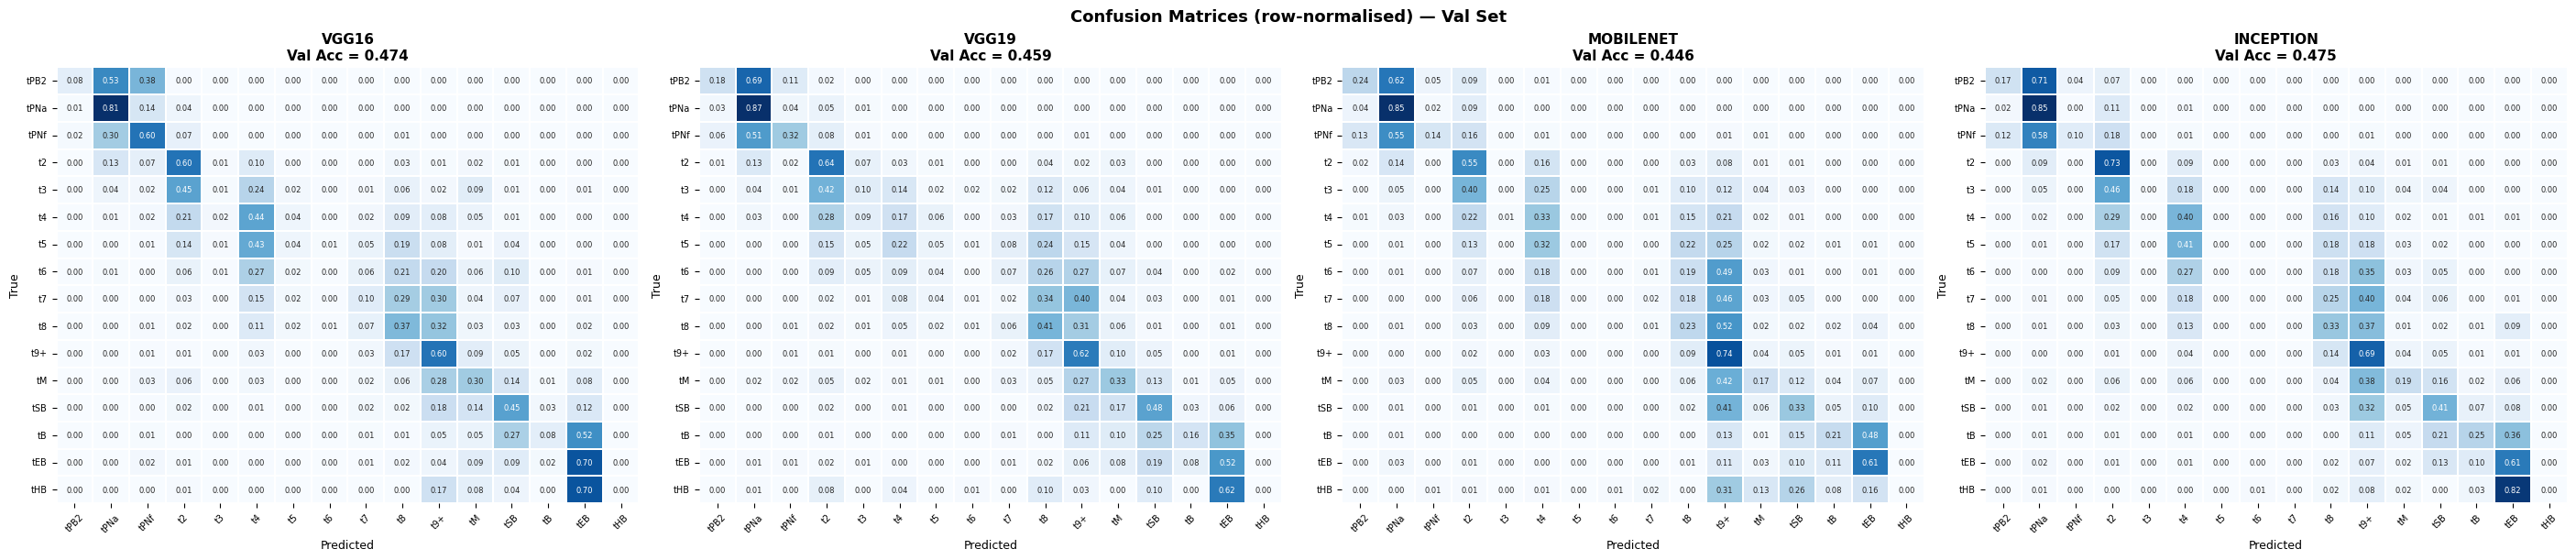

Saved → confusion_matrices.png


In [25]:
# ─────────────────────────────────────────────
# CONFUSION MATRICES — all 4 models on val set
# ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def get_predictions(model, loader, device):
    """Run model over loader, return (all_preds, all_labels) as numpy arrays."""
    all_preds, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            logits = model(imgs)
            preds  = logits.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels)


def plot_confusion_matrices(loaded_models, val_loader, device, classes):
    n = len(loaded_models)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 6), constrained_layout=True)
    if n == 1:
        axes = [axes]

    for ax, (name, model) in zip(axes, loaded_models.items()):
        # pick the right val loader
        loader = inception_val_loader if name == 'inception' else standard_val_loader
        preds, labels = get_predictions(model, loader, device)

        cm = confusion_matrix(labels, preds)
        # normalise per true class so colours show recall
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        sns.heatmap(
            cm_norm,
            ax          = ax,
            annot       = True,
            fmt         = '.2f',
            cmap        = 'Blues',
            xticklabels = classes,
            yticklabels = classes,
            linewidths  = 0.3,
            cbar        = False,
            annot_kws   = {'size': 6},
        )
        ax.set_title(f"{name.upper()}\nVal Acc = {(preds == labels).mean():.3f}",
                     fontsize=11, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=9)
        ax.set_ylabel('True',      fontsize=9)
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.tick_params(axis='y', rotation=0,  labelsize=7)

        # print per-class report
        print(f"\n── {name.upper()} ──────────────────────────────────")
        print(classification_report(labels, preds, target_names=classes, digits=3))

    plt.suptitle('Confusion Matrices (row-normalised) — Val Set',
                 fontsize=13, fontweight='bold')
    plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → confusion_matrices.png")


plot_confusion_matrices(loaded_models, standard_val_loader, DEVICE, CLASSES)


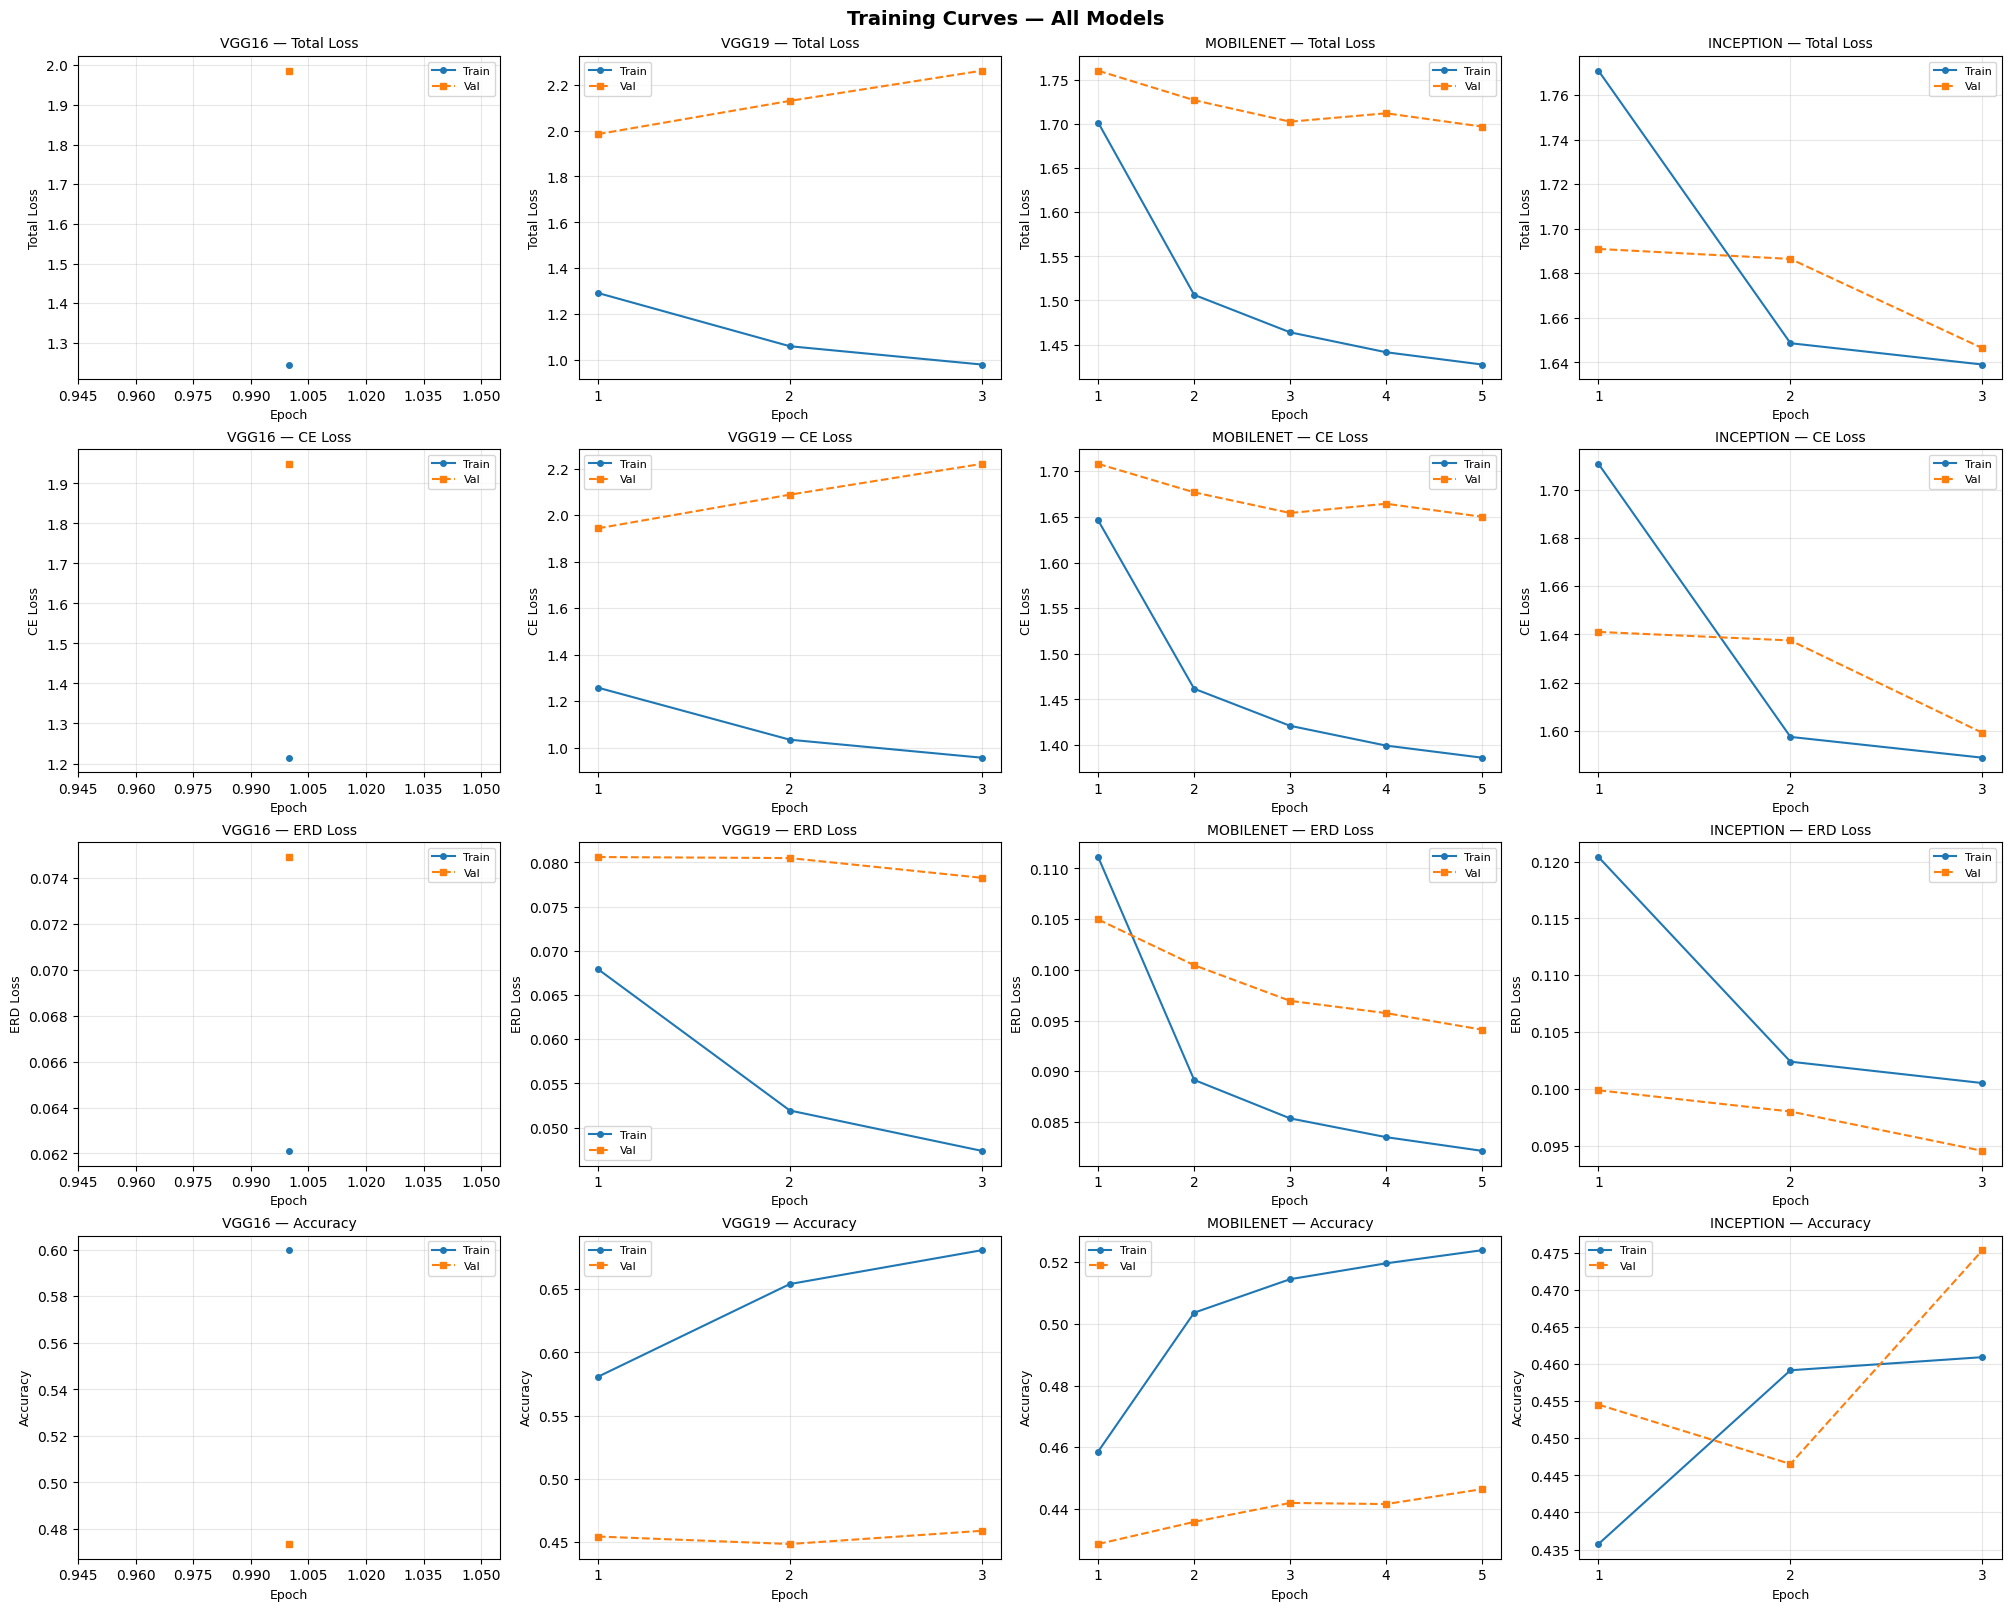

Saved → loss_curves.png


In [27]:
# ─────────────────────────────────────────────
# LOSS CURVES — all 4 models
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt

def plot_losses(all_histories):
    models_list = list(all_histories.keys())
    metrics     = [
        ('train_loss', 'val_loss', 'Total Loss'),
        ('train_ce',   'val_ce',   'CE Loss'),
        ('train_dist', 'val_dist', 'ERD Loss'),
        ('train_acc',  'val_acc',  'Accuracy'),
    ]

    fig, axes = plt.subplots(
        len(metrics), len(models_list),
        figsize=(5 * len(models_list), 4 * len(metrics)),
        constrained_layout=True,
    )
    if len(models_list) == 1:
        axes = [[ax] for ax in axes]

    for col, model_name in enumerate(models_list):
        h      = all_histories[model_name]
        epochs = range(1, len(h['train_loss']) + 1)  # ← per-model, not global

        for row, (train_key, val_key, title) in enumerate(metrics):
            ax = axes[row][col]
            ax.plot(epochs, h[train_key], label='Train', marker='o', markersize=4, linewidth=1.5)
            ax.plot(epochs, h[val_key],   label='Val',   marker='s', markersize=4,
                    linewidth=1.5, linestyle='--')
            ax.set_title(f"{model_name.upper()} — {title}", fontsize=10)
            ax.set_xlabel('Epoch', fontsize=9)
            ax.set_ylabel(title,   fontsize=9)
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    plt.suptitle('Training Curves — All Models', fontsize=14, fontweight='bold')
    plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → loss_curves.png")

plot_losses(all_histories)